# 06 - 本地 RQAlphaPlus 策略回测
本 Notebook **只在本地授权环境运行**，不在 Colab 运行。它从 YAML 的 `backtest` 段读取全部参数并显式传给回测程序，命令行参数仅用于有意覆盖配置。

In [7]:
from pathlib import Path
import os

if not Path('configs/daily/training.yaml').exists():
    repo = os.environ.get('ALPHAMINING_REPO_URL', 'https://github.com/JacksonChiy/AlphaMining-GFlowNet-AlphaEval.git')
    !git clone $repo
    %cd AlphaMining-GFlowNet-AlphaEval

## 1. 导入 Colab 训练产物

In [8]:
from zipfile import ZipFile

archive_path = Path('alphamining_colab_outputs.zip')
prediction_path = Path('results/lightgbm/prediction_score.csv')
if not prediction_path.exists():
    if not archive_path.exists():
        raise FileNotFoundError('请把 Colab 下载的 alphamining_colab_outputs.zip 放到仓库根目录')
    with ZipFile(archive_path) as archive:
        archive.extractall('.')
# assert prediction_path.exists(), '压缩包中缺少 prediction_score.csv'
print('已加载 Colab 预测分数:', prediction_path.resolve())

已加载 Colab 预测分数: /Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/results/lightgbm/prediction_score.csv


## 2. 加载并确认回测配置
默认读取本地正式配置。若需要复现 Colab 冻结配置，可把路径改为 `results/colab_training_config.yaml`。

In [5]:
import json
from rqalpha_strategy.run_backtest import load_backtest_settings

BACKTEST_CONFIG_PATH = Path('configs/daily/training.yaml')
backtest_settings = load_backtest_settings(BACKTEST_CONFIG_PATH)
print('回测配置来源:', BACKTEST_CONFIG_PATH.resolve())
print(json.dumps(backtest_settings, ensure_ascii=False, indent=2))

回测配置来源: /Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/configs/daily/training.yaml
{
  "initial_cash": 10000000.0,
  "benchmark": "000852.XSHG",
  "top_n": 20,
  "rebalance_days": 5,
  "slippage": 0.001,
  "cash_buffer": 0.98,
  "rank_smoothing_weights": [
    0.5,
    0.3,
    0.2
  ],
  "hold_buffer_rank": 100,
  "max_replacement_ratio": 0.25,
  "min_holding_days": 10
}


## 3. 运行 RQAlphaPlus
执行前会打印最终生效参数，并保存到 `results/backtest_report/backtest_effective_config.json`。

In [6]:
import subprocess
import sys

RQALPHA_PLUS_BUNDLE = Path('~/.rqalpha-plus/bundle').expanduser()  # 修改为本地已授权的数据包路径
command = [
    sys.executable, '-m', 'rqalpha_strategy.run_backtest',
    '--config', str(BACKTEST_CONFIG_PATH),
    '--bundle', str(RQALPHA_PLUS_BUNDLE),
    '--predictions', str(prediction_path),
    '--output-dir', 'results/backtest_report',
]
print('执行命令:', ' '.join(command))
subprocess.run(command, check=True)

执行命令: /opt/miniconda3/envs/rqsdk/bin/python -m rqalpha_strategy.run_backtest --config configs/daily/training.yaml --bundle /Users/jacksonchi/.rqalpha-plus/bundle --predictions results/lightgbm/prediction_score.csv --output-dir results/backtest_report


Traceback (most recent call last):
  File "/opt/miniconda3/envs/rqsdk/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/miniconda3/envs/rqsdk/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/rqalpha_strategy/run_backtest.py", line 260, in <module>
    main()
  File "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/rqalpha_strategy/run_backtest.py", line 256, in main
    run(args)
  File "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/rqalpha_strategy/run_backtest.py", line 171, in run
    config = build_config(
  File "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/rqalpha_strategy/run_backtest.py", line 92, in build_config
    scores = pd.read_csv(predictions, usecols=["signal_date"])
  File "/opt/miniconda3/envs/rqsdk/lib/python3.9/site-packages/pandas/io/parse

CalledProcessError: Command '['/opt/miniconda3/envs/rqsdk/bin/python', '-m', 'rqalpha_strategy.run_backtest', '--config', 'configs/daily/training.yaml', '--bundle', '/Users/jacksonchi/.rqalpha-plus/bundle', '--predictions', 'results/lightgbm/prediction_score.csv', '--output-dir', 'results/backtest_report']' returned non-zero exit status 1.

## 4. 校验实际生效参数并展示净值曲线

参数校验通过: {
  "predictions": "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/results/lightgbm/prediction_score.csv",
  "bundle": "/Users/jacksonchi/.rqalpha-plus/bundle",
  "output_dir": "/Users/jacksonchi/Documents/Quant 2/AlphaMining-GFlowNet-AlphaEval/results/backtest_report",
  "initial_cash": 10000000.0,
  "benchmark": "000852.XSHG",
  "top_n": 20,
  "rebalance_days": 5,
  "slippage": 0.001,
  "cash_buffer": 0.98,
  "rank_smoothing_weights": [
    0.5,
    0.3,
    0.2
  ],
  "hold_buffer_rank": 100,
  "max_replacement_ratio": 0.25,
  "min_holding_days": 10
}


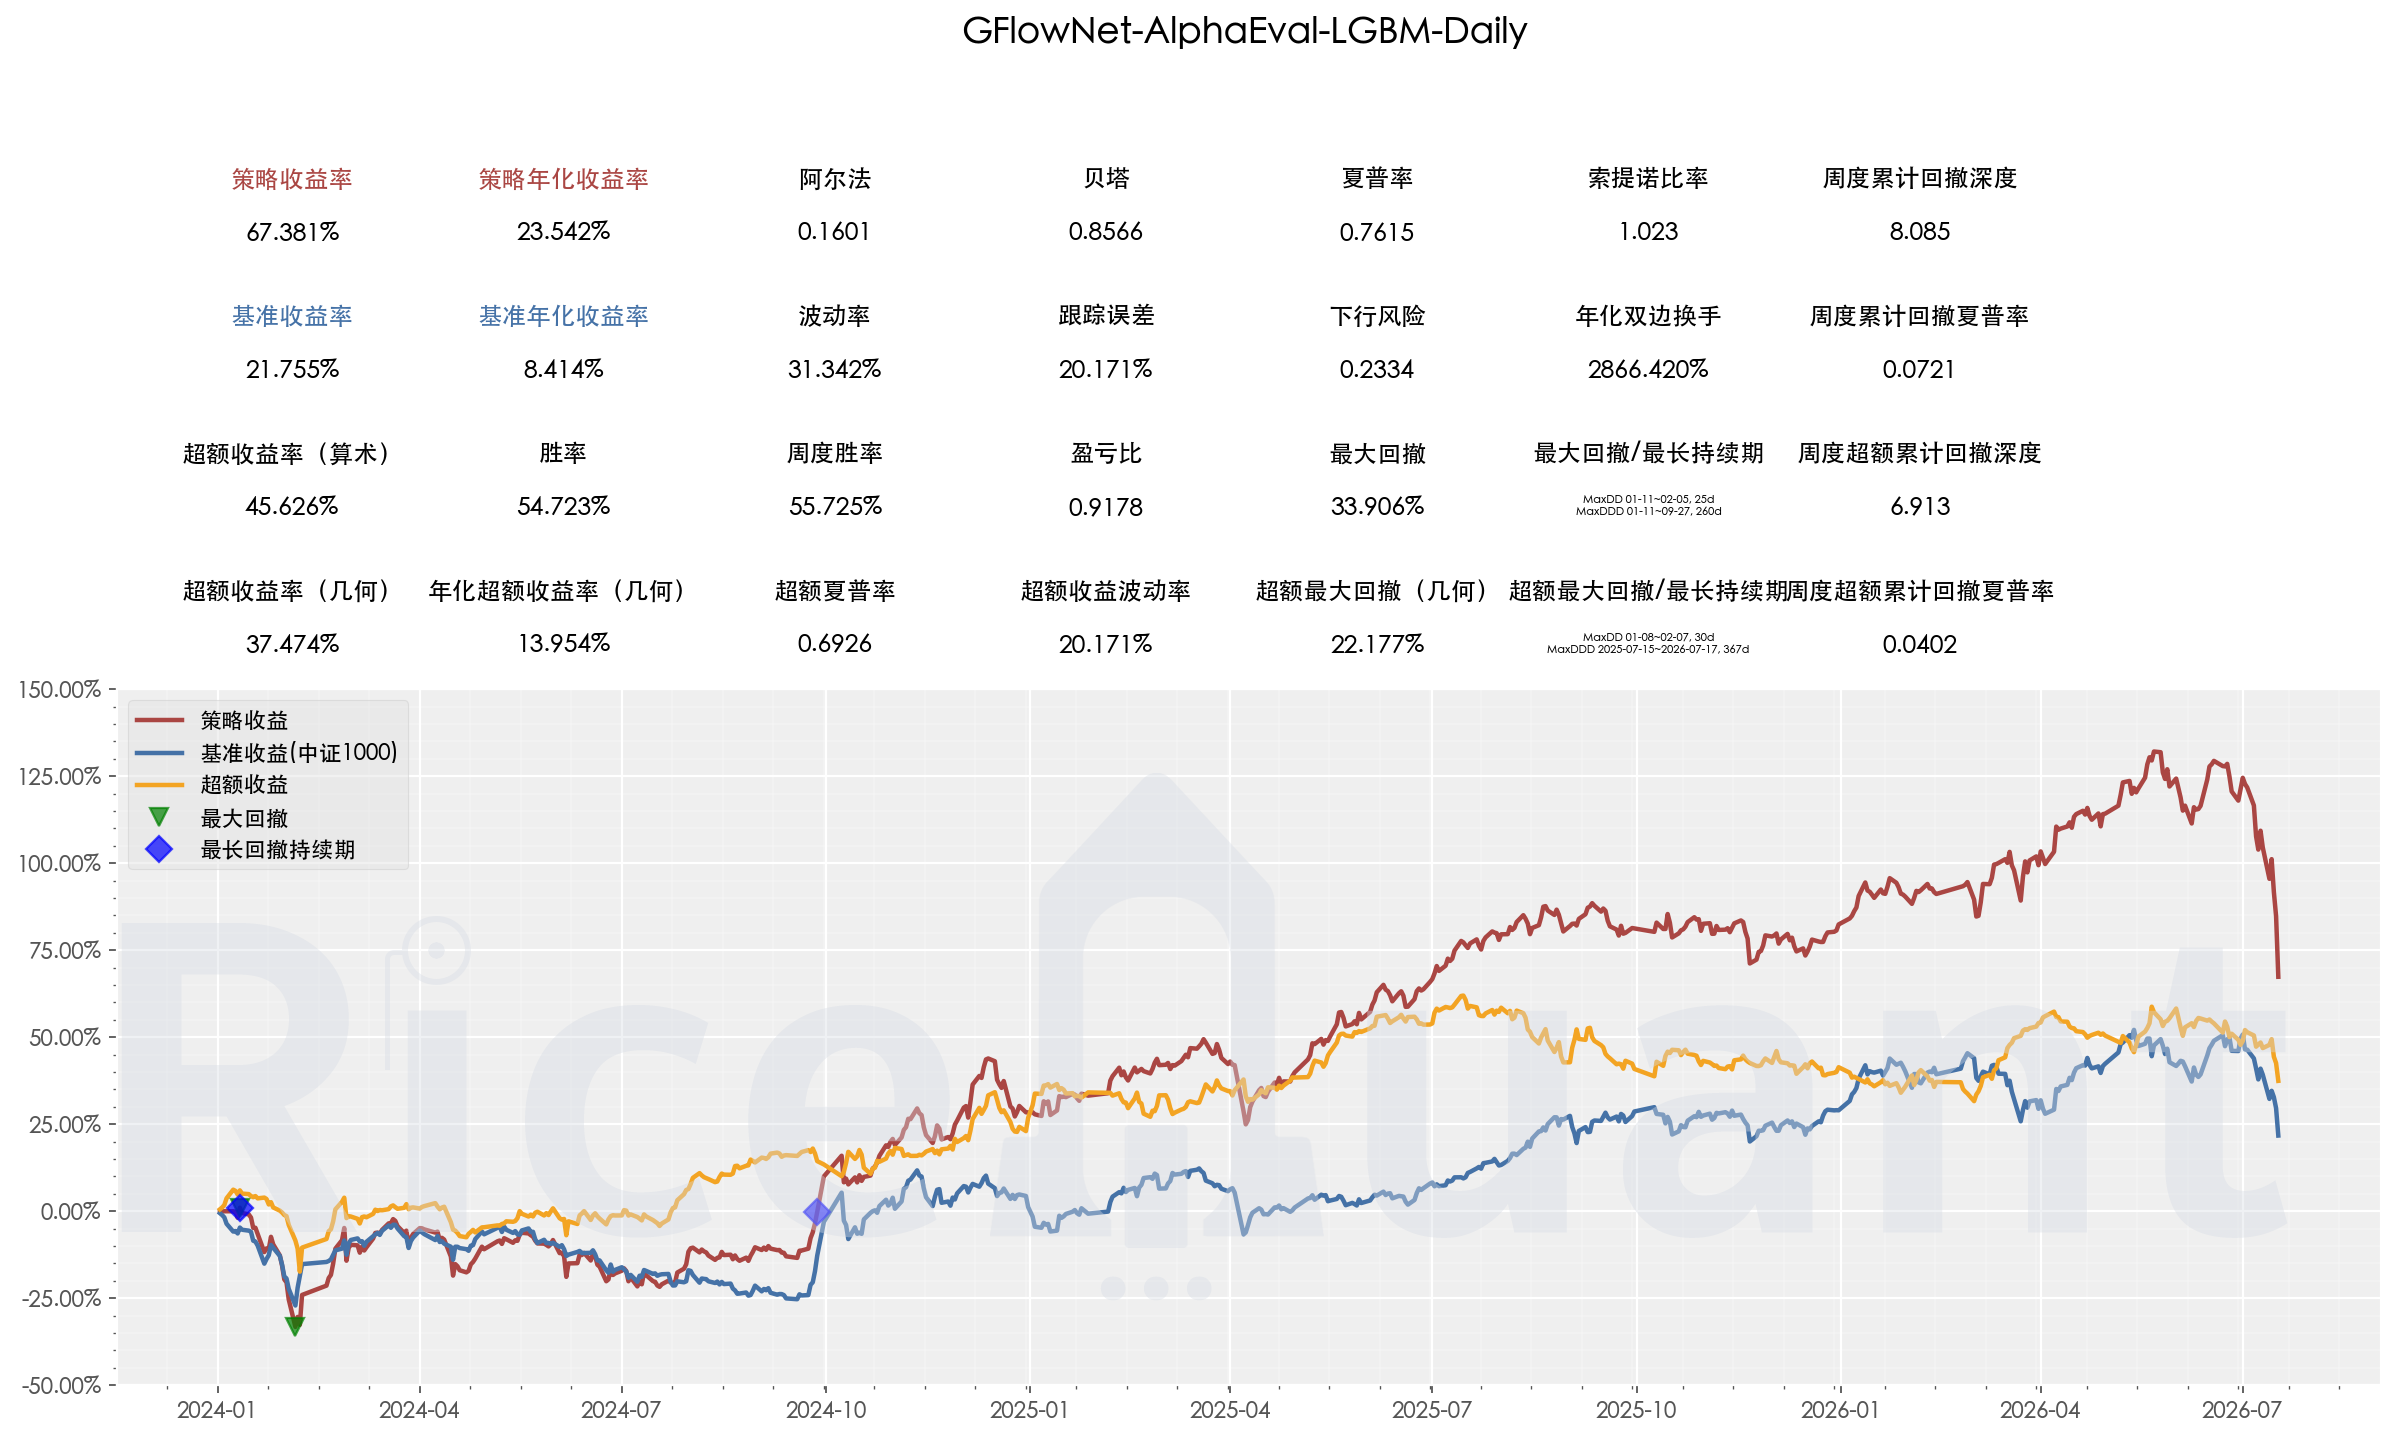

In [13]:
effective_path = Path('results/backtest_report/backtest_effective_config.json')
effective = json.loads(effective_path.read_text(encoding='utf-8'))
for key in backtest_settings:
    assert effective[key] == backtest_settings[key], f'{key} 未按配置生效: {effective[key]} != {backtest_settings[key]}'
print('参数校验通过:', json.dumps(effective, ensure_ascii=False, indent=2))

from IPython.display import Image, display
display(Image('results/backtest_report/equity_curve.png'))